# ViPER: Vision Positional Encoding Representation with Hierarchical Dynamic Wavelet Encoding

**Ablation Study on EuroSAT — Colab Notebook**

This notebook runs the full ViPER ablation study:
1. Setup & GPU check
2. Install dependencies
3. Define all PE methods (7 baselines + ViPER)
4. Configure ablation
5. Load EuroSAT
6. Run baselines
7. Run Stage 1 ablation (Q1, Q3, Q4, Q7)
8. Run Stage 2 ablation (Q5, Q6, Q8, SCA)
9. Final report + plots

**Tip:** In Colab, set Runtime → Change runtime type → **GPU** (T4 or better) before running.

## 1. Setup and GPU check

In [ ]:
# Verify GPU is available
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available:  {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:             {torch.cuda.get_device_name(0)}")
    print(f"Memory:          {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: No GPU. Ablation will be slow. In Colab: Runtime → Change runtime type → GPU.")


PyTorch version: 2.10.0+cu128
CUDA available:  True
GPU:             Tesla T4
Memory:          15.6 GB


## 2. Install dependencies

In [ ]:
# Install pytorch_wavelets (other deps come pre-installed in Colab)
!pip install -q pytorch_wavelets pywavelets
print("Dependencies installed.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 2.2 MB/s eta 0:00:00
Dependencies installed.


## 3. Imports

In [ ]:
import math
import time
import json
import warnings
from dataclasses import dataclass, field, asdict
from pathlib import Path
from typing import Dict, List, Optional, Tuple

warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset

import torchvision.transforms as T
from torchvision.datasets import EuroSAT

from sklearn.metrics import f1_score, roc_auc_score

from pytorch_wavelets import DWTForward, DWTInverse

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")


Device: cuda


## 4. ViPER Configuration

The `ViPERConfig` dataclass exposes all 8 ablation axes plus SCA. Every ViPER
variant in the ablation is a different instance of this config.

In [ ]:
@dataclass
class ViPERConfig:
    """All eight ablation axes + SCA."""
    # Q1: where DWT is applied
    dwt_location:    str = "raw_image"      # 'raw_image' | 'per_patch' | 'patch_embedding'
    # Q2: how coefficients map to patches
    coef_to_patch:   str = "avg_pool"       # 'avg_pool' | 'bilinear' | 'direct'
    # Q3: how PE is injected
    injection:       str = "additive"       # 'additive' | 'rotary' | 'concat'
    # Q4: number of decomposition levels
    n_levels:        int = 3
    # Q5: wavelet basis
    wavelet:         str = "db4"
    # Q6: color-channel handling
    channel_mode:    str = "gray"           # 'gray' | 'per_channel_concat' | 'learnable_proj'
    # Q7: sub-band fusion within a level
    subband_fusion:  str = "gated"          # 'concat' | 'weighted_sum' | 'gated'
    # Q8: how levels are combined
    level_combine:   str = "alw"            # 'sum' | 'concat' | 'weighted' | 'alw'
    # Bonus: Spatial Context Aggregation
    sca:             bool = True


## 5. Baseline positional encodings

Seven baselines: NoPE, Learned APE, 2D Sin-Cos, RoPE-2D, Relative-2D (Swin), CPE, iRPE.

In [ ]:
class NoPE(nn.Module):
    def forward(self, x, image=None): return x


class LearnedPE(nn.Module):
    """Standard learned APE (ViT default)."""
    def __init__(self, num_tokens, d_model):
        super().__init__()
        self.pe = nn.Parameter(torch.randn(1, num_tokens, d_model) * 0.02)
    def forward(self, x, image=None):
        return x + self.pe[:, : x.shape[1]]


class SinCos2DPE(nn.Module):
    """Fixed 2D sin-cos PE (DeiT/MAE)."""
    def __init__(self, H, W, d_model):
        super().__init__()
        assert d_model % 4 == 0
        d_q = d_model // 4
        y = torch.arange(H, dtype=torch.float32).unsqueeze(1)
        x = torch.arange(W, dtype=torch.float32).unsqueeze(1)
        w = 1.0 / (10000 ** (torch.arange(d_q, dtype=torch.float32) / d_q))
        enc_h = torch.cat([torch.sin(y*w), torch.cos(y*w)], dim=-1)
        enc_w = torch.cat([torch.sin(x*w), torch.cos(x*w)], dim=-1)
        enc_h = enc_h.unsqueeze(1).expand(H, W, -1)
        enc_w = enc_w.unsqueeze(0).expand(H, W, -1)
        pe = torch.cat([enc_h, enc_w], dim=-1).reshape(1, H*W, d_model)
        cls_pe = torch.zeros(1, 1, d_model)
        self.register_buffer("pe", torch.cat([cls_pe, pe], dim=1))
    def forward(self, x, image=None):
        return x + self.pe[:, : x.shape[1]]


class RoPE2D(nn.Module):
    """2D Rotary PE: independent axial RoPE for rows and columns."""
    def __init__(self, H, W, d_model):
        super().__init__()
        assert d_model % 4 == 0
        self.H, self.W = H, W
        self.half = d_model // 2
        self.quarter = d_model // 4
        inv_freq = 1.0 / (10000 ** (torch.arange(0, self.quarter, dtype=torch.float32) / self.quarter))
        self.register_buffer("inv_freq", inv_freq)
    def _axis(self, pos):
        f = torch.outer(pos.float(), self.inv_freq)
        f = torch.cat([f, f], dim=-1)
        return f.cos(), f.sin()
    @staticmethod
    def _rotate(x, c, s):
        x1, x2 = x[..., : x.shape[-1]//2], x[..., x.shape[-1]//2:]
        return torch.cat([x1*c - x2*s, x1*s + x2*c], dim=-1)
    def forward(self, x, image=None):
        cls, pts = x[:, :1], x[:, 1:]
        device = x.device
        rows = torch.arange(self.H, device=device).repeat_interleave(self.W)
        cols = torch.arange(self.W, device=device).repeat(self.H)
        ch, sh = self._axis(rows); cw, sw = self._axis(cols)
        ph = self._rotate(pts[..., :self.half], ch, sh)
        pw = self._rotate(pts[..., self.half:], cw, sw)
        return torch.cat([cls, torch.cat([ph, pw], dim=-1)], dim=1)


class Relative2DPE(nn.Module):
    """Swin-style relative position bias as additive PE."""
    def __init__(self, H, W, d_model):
        super().__init__()
        self.H, self.W = H, W
        self.rel_h = nn.Embedding(2*H - 1, d_model // 2)
        self.rel_w = nn.Embedding(2*W - 1, d_model // 2)
        self.cls_pe = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)
    def forward(self, x, image=None):
        B, _, _ = x.shape
        device = x.device
        rows = torch.arange(self.H, device=device).repeat_interleave(self.W)
        cols = torch.arange(self.W, device=device).repeat(self.H)
        rel_r = (rows.unsqueeze(1) - rows.unsqueeze(0)) + (self.H - 1)
        rel_c = (cols.unsqueeze(1) - cols.unsqueeze(0)) + (self.W - 1)
        emb_r = self.rel_h(rel_r).mean(dim=1)
        emb_c = self.rel_w(rel_c).mean(dim=1)
        pe = torch.cat([emb_r, emb_c], dim=-1).unsqueeze(0).expand(B, -1, -1)
        cls = self.cls_pe.expand(B, -1, -1)
        return x + torch.cat([cls, pe], dim=1)


class CPE(nn.Module):
    """Conditional PE (Chu et al. 2021): depthwise conv injects position."""
    def __init__(self, H, W, d_model, k=3):
        super().__init__()
        self.H, self.W = H, W
        self.proj = nn.Conv2d(d_model, d_model, k, padding=k//2, groups=d_model)
        self.cls_pe = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)
    def forward(self, x, image=None):
        cls, pts = x[:, :1], x[:, 1:]
        B, N, C = pts.shape
        sp = pts.transpose(1, 2).reshape(B, C, self.H, self.W)
        sp = self.proj(sp) + sp
        pts = sp.flatten(2).transpose(1, 2)
        return torch.cat([cls + self.cls_pe.expand(B, -1, -1), pts], dim=1)


class iRPE(nn.Module):
    """
    Simplified iRPE (Wu et al. 2021): bucketed 2D relative bias.
    Note: this is the additive variant; the full iRPE adds bias to attention logits.
    """
    def __init__(self, H, W, d_model, n_buckets=16):
        super().__init__()
        self.H, self.W = H, W
        self.n_buckets = n_buckets
        self.embed = nn.Embedding(n_buckets * n_buckets, d_model)
        self.cls_pe = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)
    def _bucket(self, x, n):
        sign = torch.sign(x); x = torch.abs(x).float()
        log_max = math.log(n/2 + 1)
        idx = (torch.log(x + 1) / log_max * (n/2)).long().clamp(max=n//2 - 1)
        return ((sign.long() + 1) * (n//2) + idx).clamp(0, n - 1)
    def forward(self, x, image=None):
        B = x.shape[0]; device = x.device
        rows = torch.arange(self.H, device=device).repeat_interleave(self.W)
        cols = torch.arange(self.W, device=device).repeat(self.H)
        br = self._bucket(rows - rows.float().mean(), self.n_buckets)
        bc = self._bucket(cols - cols.float().mean(), self.n_buckets)
        idx = br * self.n_buckets + bc
        pe = self.embed(idx).unsqueeze(0).expand(B, -1, -1)
        cls = self.cls_pe.expand(B, -1, -1)
        return x + torch.cat([cls, pe], dim=1)


## 6. ViPER module (configurable across Q1–Q8 + SCA)

The single `ViPER` class implements the entire design space. Each ablation run
is just a different `ViPERConfig`.

In [ ]:
class ViPER(nn.Module):
    """
    Vision Positional Encoding Representation with Hierarchical Dynamic
    Wavelet Encoding. All ablation axes exposed via ViPERConfig.
    """
    def __init__(self, cfg, d_model, H_p, W_p, image_h, image_w,
                 in_channels=3, patch_size=8, include_cls=True):
        super().__init__()
        self.cfg = cfg
        self.d_model = d_model
        self.H_p, self.W_p = H_p, W_p
        self.image_h, self.image_w = image_h, image_w
        self.in_channels = in_channels
        self.patch_size = patch_size
        self.include_cls = include_cls

        self.dwt = DWTForward(J=cfg.n_levels, wave=cfg.wavelet, mode="symmetric")

        # Q6: channel handling (only for raw_image / per_patch)
        if cfg.dwt_location in ("raw_image", "per_patch"):
            if cfg.channel_mode == "gray":
                self.dwt_in_channels = 1
                self.register_buffer("rgb2gray", torch.tensor([0.299, 0.587, 0.114]).view(1, 3, 1, 1))
            elif cfg.channel_mode == "per_channel_concat":
                self.dwt_in_channels = in_channels
            elif cfg.channel_mode == "learnable_proj":
                self.channel_proj = nn.Conv2d(in_channels, 1, 1, bias=False)
                self.dwt_in_channels = 1
        else:
            self.dwt_in_channels = d_model  # patch_embedding case

        self.subband_proj = nn.Conv2d(self.dwt_in_channels, d_model, 1)

        # Q7: sub-band fusion
        if cfg.subband_fusion == "concat":
            self.subband_combine = nn.Conv2d(4 * d_model, d_model, 1)
        elif cfg.subband_fusion == "weighted_sum":
            self.subband_weights = nn.Parameter(torch.ones(cfg.n_levels, 4) / 4)
        elif cfg.subband_fusion == "gated":
            num_subbands = 1 + cfg.n_levels * 3
            self.scale_embeddings = nn.Parameter(torch.randn(num_subbands, d_model))
            self.gate_w_g = nn.Linear(d_model, d_model)
            self.gate_w_v = nn.Linear(d_model, d_model)

        # Q8: level combination
        if cfg.level_combine == "concat":
            self.level_combine_proj = nn.Conv2d((cfg.n_levels + 1) * d_model, d_model, 1)
        elif cfg.level_combine == "weighted":
            self.level_weights = nn.Parameter(torch.ones(cfg.n_levels + 1) / (cfg.n_levels + 1))
        elif cfg.level_combine == "alw":
            self.alw_mlp = nn.Sequential(
                nn.AdaptiveAvgPool2d(1),
                nn.Flatten(),
                nn.Linear(d_model, cfg.n_levels + 1),
            )

        # SCA
        if cfg.sca:
            self.sca_conv = nn.Conv2d(d_model, d_model, 3, padding=1, groups=d_model, bias=False)
            self.sca_norm = nn.GroupNorm(1, d_model)

        # Q3: injection
        if cfg.injection == "concat":
            self.injection_proj = nn.Linear(2 * d_model, d_model)

        if include_cls:
            self.cls_pe = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)

    @staticmethod
    def _fit(x, H, W):
        _, _, h, w = x.shape
        if h > H or w > W: x = x[:, :, :H, :W]
        if h < H or w < W: x = F.pad(x, (0, max(0, W - w), 0, max(0, H - h)))
        return x

    def _prepare_input(self, image):
        if self.cfg.channel_mode == "gray":
            return (image * self.rgb2gray).sum(dim=1, keepdim=True)
        elif self.cfg.channel_mode == "per_channel_concat":
            return image
        elif self.cfg.channel_mode == "learnable_proj":
            return self.channel_proj(image)

    def _project_subband(self, coeffs):
        if coeffs.shape[1] == self.d_model: return coeffs
        return self.subband_proj(coeffs)

    def _coef_to_patch_grid(self, coeffs):
        method = self.cfg.coef_to_patch
        H_t, W_t = self.H_p, self.W_p
        _, _, h, w = coeffs.shape
        if method == "avg_pool":
            if h >= H_t and w >= W_t:
                return F.adaptive_avg_pool2d(coeffs, (H_t, W_t))
            return F.interpolate(coeffs, size=(H_t, W_t), mode="bilinear", align_corners=False)
        elif method == "bilinear":
            return F.interpolate(coeffs, size=(H_t, W_t), mode="bilinear", align_corners=False)
        elif method == "direct":
            return self._fit(coeffs, H_t, W_t)

    def _gated_modulate(self, coeffs, idx):
        e = self.scale_embeddings[idx]
        g = torch.sigmoid(self.gate_w_g(e))
        v = torch.tanh(self.gate_w_v(e))
        return coeffs * (g * v).view(1, self.d_model, 1, 1)

    def forward(self, x, image=None):
        B = x.shape[0]
        if self.include_cls:
            cls, pts = x[:, :1], x[:, 1:]
        else:
            pts = x

        # Q1: prepare DWT input
        if self.cfg.dwt_location == "raw_image":
            sp = self._prepare_input(image)
        elif self.cfg.dwt_location == "per_patch":
            sp = self._prepare_input(image)
            B_, C_, H_, W_ = sp.shape
            P = self.patch_size
            sp = sp.unfold(2, P, P).unfold(3, P, P)
            sp = sp.contiguous().view(B_, C_, -1, P, P).permute(0, 2, 1, 3, 4)
            sp = sp.reshape(-1, C_, P, P)
        elif self.cfg.dwt_location == "patch_embedding":
            sp = pts.reshape(B, self.H_p, self.W_p, self.d_model).permute(0, 3, 1, 2)

        # SCA (only meaningful at patch_embedding)
        if self.cfg.sca and self.cfg.dwt_location == "patch_embedding":
            sp = self.sca_norm(self.sca_conv(sp)) + sp

        # DWT
        Yl, Yh = self.dwt(sp)
        Yl_d = self._project_subband(Yl)
        if self.cfg.dwt_location == "raw_image":
            Yl_d = self._coef_to_patch_grid(Yl_d)

        per_level_pe = []

        # Q7: sub-band fusion
        if self.cfg.subband_fusion == "gated":
            per_level_pe.append(self._gated_modulate(Yl_d, 0))
            for li in range(self.cfg.n_levels):
                detail = Yh[li]
                fused = 0
                for si in range(3):
                    band = detail[:, :, si]
                    band_d = self._project_subband(band)
                    if self.cfg.dwt_location == "raw_image":
                        band_d = self._coef_to_patch_grid(band_d)
                    fused = fused + self._gated_modulate(band_d, 1 + li*3 + si)
                per_level_pe.append(fused)
        elif self.cfg.subband_fusion == "weighted_sum":
            per_level_pe.append(Yl_d)
            for li in range(self.cfg.n_levels):
                detail = Yh[li]
                w = torch.softmax(self.subband_weights[li], dim=0)
                level_pe = 0
                for si in range(3):
                    band = detail[:, :, si]
                    band_d = self._project_subband(band)
                    if self.cfg.dwt_location == "raw_image":
                        band_d = self._coef_to_patch_grid(band_d)
                    level_pe = level_pe + w[si + 1] * band_d
                per_level_pe.append(level_pe)
        elif self.cfg.subband_fusion == "concat":
            per_level_pe.append(Yl_d)
            for li in range(self.cfg.n_levels):
                detail = Yh[li]
                bands = [Yl_d]
                for si in range(3):
                    band = detail[:, :, si]
                    band_d = self._project_subband(band)
                    if self.cfg.dwt_location == "raw_image":
                        band_d = self._coef_to_patch_grid(band_d)
                    bands.append(band_d)
                per_level_pe.append(self.subband_combine(torch.cat(bands, dim=1)))

        # per_patch: pool spatial dim and reshape to patch grid
        if self.cfg.dwt_location == "per_patch":
            new_levels = []
            for lpe in per_level_pe:
                pooled = F.adaptive_avg_pool2d(lpe, 1).squeeze(-1).squeeze(-1)
                pooled = pooled.view(B, self.H_p, self.W_p, self.d_model).permute(0, 3, 1, 2)
                new_levels.append(pooled)
            per_level_pe = new_levels

        # Q8: combine levels
        if self.cfg.level_combine == "sum":
            pe_sp = sum(per_level_pe)
        elif self.cfg.level_combine == "weighted":
            w = torch.softmax(self.level_weights, dim=0)
            pe_sp = sum(wi * pi for wi, pi in zip(w, per_level_pe))
        elif self.cfg.level_combine == "concat":
            pe_sp = self.level_combine_proj(torch.cat(per_level_pe, dim=1))
        elif self.cfg.level_combine == "alw":
            ll_for_gate = per_level_pe[0]
            w = torch.softmax(self.alw_mlp(ll_for_gate), dim=-1)
            pe_sp = 0
            for i, pi in enumerate(per_level_pe):
                pe_sp = pe_sp + w[:, i].view(B, 1, 1, 1) * pi

        pe_sp = self._fit(pe_sp, self.H_p, self.W_p)
        pe_seq = pe_sp.permute(0, 2, 3, 1).reshape(B, self.H_p * self.W_p, self.d_model)

        # Q3: inject
        if self.cfg.injection == "additive":
            pts_out = pts + pe_seq
        elif self.cfg.injection == "concat":
            pts_out = self.injection_proj(torch.cat([pts, pe_seq], dim=-1))
        elif self.cfg.injection == "rotary":
            half = self.d_model // 2
            cos_t = torch.cos(pe_seq[..., :half])
            sin_t = torch.sin(pe_seq[..., :half])
            x1, x2 = pts[..., :half], pts[..., half:]
            pts_out = torch.cat([x1*cos_t - x2*sin_t, x1*sin_t + x2*cos_t], dim=-1)

        if self.include_cls:
            cls = cls + self.cls_pe.expand(B, -1, -1)
            return torch.cat([cls, pts_out], dim=1)
        return pts_out


## 7. ViT backbone

In [ ]:
class PatchEmbed(nn.Module):
    def __init__(self, in_ch, P, d, H, W):
        super().__init__()
        self.P = P
        self.pad_h = (P - H % P) % P
        self.pad_w = (P - W % P) % P
        H_e, W_e = H + self.pad_h, W + self.pad_w
        self.H_p, self.W_p = H_e // P, W_e // P
        self.num_patches = self.H_p * self.W_p
        self.proj = nn.Conv2d(in_ch, d, P, P)
        self.cls = nn.Parameter(torch.randn(1, 1, d) * 0.02)
    def forward(self, x):
        if self.pad_h or self.pad_w:
            x = F.pad(x, (0, self.pad_w, 0, self.pad_h))
        x = self.proj(x).flatten(2).transpose(1, 2)
        return torch.cat([self.cls.expand(x.shape[0], -1, -1), x], dim=1)


class ViT(nn.Module):
    def __init__(self, image_h, image_w, in_channels, patch_size, d_model,
                 num_layers, num_heads, mlp_dim, num_classes, dropout,
                 pe_type, viper_cfg=None):
        super().__init__()
        self.patch_embed = PatchEmbed(in_channels, patch_size, d_model, image_h, image_w)
        H_p, W_p = self.patch_embed.H_p, self.patch_embed.W_p
        N = self.patch_embed.num_patches
        self.pe_type = pe_type
        self.pe = self._build_pe(pe_type, d_model, H_p, W_p, N, image_h, image_w,
                                 in_channels, patch_size, viper_cfg)
        layer = nn.TransformerEncoderLayer(d_model, num_heads, mlp_dim, dropout,
                                           batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(layer, num_layers)
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, num_classes)
        self._init_weights()

    def _build_pe(self, t, d, H, W, N, im_h, im_w, ic, P, vcfg):
        if t == "none":       return NoPE()
        if t == "learned":    return LearnedPE(N + 1, d)
        if t == "sincos2d":   return SinCos2DPE(H, W, d)
        if t == "rope2d":     return RoPE2D(H, W, d)
        if t == "relative2d": return Relative2DPE(H, W, d)
        if t == "cpe":        return CPE(H, W, d)
        if t == "irpe":       return iRPE(H, W, d)
        if t == "viper":      return ViPER(vcfg, d, H, W, im_h, im_w, ic, P)
        raise ValueError(f"Unknown PE: {t}")

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, x):
        image = x
        x = self.patch_embed(x)
        if isinstance(self.pe, ViPER):
            x = self.pe(x, image=image)
        else:
            x = self.pe(x)
        x = self.encoder(x)
        return self.head(self.norm(x[:, 0]))


## 8. Data loading, metrics, training loop

In [ ]:
def get_eurosat(data_root="./data", batch_size=64, image_size=64,
                seed=42, num_workers=2):
    mean = (0.3444, 0.3803, 0.4078)
    std  = (0.2026, 0.1365, 0.1148)
    train_tf = T.Compose([
        T.Resize((image_size, image_size)),
        T.RandomHorizontalFlip(), T.RandomVerticalFlip(),
        T.ColorJitter(0.2, 0.2, 0.1),
        T.ToTensor(), T.Normalize(mean, std),
    ])
    eval_tf = T.Compose([
        T.Resize((image_size, image_size)),
        T.ToTensor(), T.Normalize(mean, std),
    ])
    full_tr = EuroSAT(root=data_root, transform=train_tf, download=True)
    full_ev = EuroSAT(root=data_root, transform=eval_tf,  download=True)
    n = len(full_tr); n_te = int(n*0.15); n_va = int(n*0.15); n_tr = n - n_te - n_va
    g = torch.Generator().manual_seed(seed)
    idx = torch.randperm(n, generator=g).tolist()
    tr_ds = Subset(full_tr, idx[:n_tr])
    va_ds = Subset(full_ev, idx[n_tr:n_tr+n_va])
    te_ds = Subset(full_ev, idx[n_tr+n_va:])
    kw = dict(batch_size=batch_size, num_workers=num_workers, pin_memory=True)
    return (DataLoader(tr_ds, shuffle=True, **kw),
            DataLoader(va_ds, shuffle=False, **kw),
            DataLoader(te_ds, shuffle=False, **kw),
            10, image_size, image_size)


def compute_metrics(logits, labels, num_classes):
    probs = F.softmax(logits, dim=-1).cpu().numpy()
    preds = probs.argmax(axis=1)
    y = labels.cpu().numpy()
    acc = (preds == y).mean()
    f1 = f1_score(y, preds, average="macro", zero_division=0)
    try:
        auc = roc_auc_score(y, probs, multi_class="ovr", average="macro") \
              if len(np.unique(y)) == num_classes else float("nan")
    except Exception:
        auc = float("nan")
    return {"acc": float(acc), "f1": float(f1), "auc": float(auc)}


@torch.no_grad()
def evaluate(model, loader, device, num_classes):
    model.eval()
    logits_all, labels_all = [], []
    crit = nn.CrossEntropyLoss(); loss_total = 0.0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        out = model(imgs)
        loss_total += crit(out, labels).item()
        logits_all.append(out); labels_all.append(labels)
    logits = torch.cat(logits_all); labels = torch.cat(labels_all)
    m = compute_metrics(logits, labels, num_classes)
    m["loss"] = loss_total / len(loader)
    return m


def set_seed(seed):
    np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)


def train_one(pe_type, model_params, viper_cfg,
              train_loader, val_loader, test_loader,
              n_epochs=50, lr=3e-4, weight_decay=0.05,
              device=DEVICE, num_classes=10, seed=42,
              verbose=True, name=None):
    set_seed(seed)
    model = ViT(pe_type=pe_type, viper_cfg=viper_cfg, **model_params).to(device)
    n_params = sum(p.numel() for p in model.parameters())
    pe_params = sum(p.numel() for p in model.pe.parameters())
    if verbose:
        tag = name or pe_type
        print(f"[{tag}]  total={n_params:,}  PE={pe_params:,}")

    crit = nn.CrossEntropyLoss(label_smoothing=0.1)
    opt  = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)

    history = {"train_loss": [], "val": [], "epoch_times": []}
    best_val_acc = 0.0; best_state = None

    for ep in range(n_epochs):
        t0 = time.time()
        model.train(); tr_loss = 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            opt.zero_grad()
            loss = crit(model(imgs), labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            tr_loss += loss.item()
        sched.step()
        avg_tr = tr_loss / len(train_loader)
        val_m = evaluate(model, val_loader, device, num_classes)
        ep_t = time.time() - t0
        history["train_loss"].append(avg_tr)
        history["val"].append(val_m)
        history["epoch_times"].append(ep_t)
        if val_m["acc"] > best_val_acc:
            best_val_acc = val_m["acc"]
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        if verbose and (ep + 1) % max(1, n_epochs // 5) == 0:
            print(f"  ep {ep+1:3d}/{n_epochs}  tr={avg_tr:.4f}  "
                  f"val_acc={val_m['acc']:.4f}  f1={val_m['f1']:.4f}  "
                  f"auc={val_m['auc']:.4f}  t={ep_t:.1f}s")

    test_m = None
    if test_loader is not None and best_state is not None:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
        test_m = evaluate(model, test_loader, device, num_classes)
        if verbose:
            print(f"  TEST  acc={test_m['acc']:.4f}  f1={test_m['f1']:.4f}  auc={test_m['auc']:.4f}")

    return {
        "name":         name or pe_type,
        "pe_type":      pe_type,
        "viper_cfg":    asdict(viper_cfg) if viper_cfg else None,
        "seed":         seed,
        "n_params":     n_params,
        "pe_params":    pe_params,
        "best_val_acc": best_val_acc,
        "test":         test_m,
        "history":      history,
        "avg_epoch_t":  float(np.mean(history["epoch_times"])),
    }


## 9. Global experiment configuration

Edit these to control the run. **For a quick smoke test, set `EPOCHS = 3`.**
For a full run, use `EPOCHS = 50` (Tiny) or `EPOCHS = 100` (Small).

In [ ]:
# ───────────── Experiment configuration ─────────────
EPOCHS         = 50     # Set to 3 for a smoke test
BATCH_SIZE     = 64
SEED           = 42

# ViT-Tiny (good for ablation; fits T4 GPU comfortably)
PATCH_SIZE     = 8
D_MODEL        = 192
NUM_LAYERS     = 6
NUM_HEADS      = 3      # head_dim = 64
MLP_DIM        = 768
DROPOUT        = 0.1

# Optimizer
LR             = 3e-4
WEIGHT_DECAY   = 0.05

# Output dir
OUT_DIR = Path("./viper_results")
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Outputs will be saved to: {OUT_DIR.resolve()}")


Outputs will be saved to: /content/viper_results


## 10. Load EuroSAT

In [ ]:
train_loader, val_loader, test_loader, num_classes, img_h, img_w = \
    get_eurosat("./data", BATCH_SIZE, image_size=64, seed=SEED, num_workers=2)

print(f"EuroSAT loaded — {num_classes} classes, {img_h}x{img_w}")
print(f"  Train: {len(train_loader.dataset):,}")
print(f"  Val:   {len(val_loader.dataset):,}")
print(f"  Test:  {len(test_loader.dataset):,}")

# Patch grid info
pad_h = (PATCH_SIZE - img_h % PATCH_SIZE) % PATCH_SIZE
pad_w = (PATCH_SIZE - img_w % PATCH_SIZE) % PATCH_SIZE
H_p = (img_h + pad_h) // PATCH_SIZE
W_p = (img_w + pad_w) // PATCH_SIZE
print(f"Patch grid: {H_p} x {W_p} = {H_p * W_p} tokens (+ CLS)")

MODEL_PARAMS = dict(
    image_h=img_h, image_w=img_w, in_channels=3,
    patch_size=PATCH_SIZE, d_model=D_MODEL,
    num_layers=NUM_LAYERS, num_heads=NUM_HEADS,
    mlp_dim=MLP_DIM, num_classes=num_classes, dropout=DROPOUT,
)


100%|██████████| 94.3M/94.3M [00:00<00:00, 269MB/s]


EuroSAT loaded — 10 classes, 64x64
  Train: 18,900
  Val:   4,050
  Test:  4,050
Patch grid: 8 x 8 = 64 tokens (+ CLS)


## 11. Reporting utilities

In [ ]:
import pandas as pd

def results_to_df(results):
    rows = []
    for r in results:
        t = r["test"] or {}
        rows.append({
            "name":         r["name"],
            "pe_type":      r["pe_type"],
            "test_acc":     t.get("acc"),
            "test_f1":      t.get("f1"),
            "test_auc":     t.get("auc"),
            "best_val_acc": r["best_val_acc"],
            "pe_params":    r["pe_params"],
            "epoch_t":      r["avg_epoch_t"],
        })
    df = pd.DataFrame(rows).sort_values("test_acc", ascending=False)
    return df.reset_index(drop=True)


def save_results(results, tag):
    with open(OUT_DIR / f"{tag}_results.json", "w") as f:
        json.dump(results, f, indent=2, default=str)
    df = results_to_df(results)
    df.to_csv(OUT_DIR / f"{tag}_summary.csv", index=False)
    return df


def plot_ablation(results, title):
    names = [r["name"] for r in results]
    accs = [(r["test"]["acc"] if r["test"] else r["best_val_acc"]) for r in results]
    f1s  = [(r["test"]["f1"]  if r["test"] else float("nan"))      for r in results]
    aucs = [(r["test"]["auc"] if r["test"] else float("nan"))      for r in results]
    fig, ax = plt.subplots(1, 3, figsize=(18, 5))
    for a, vals, ttl in zip(ax, [accs, f1s, aucs], ["Accuracy", "Macro F1", "AUC (OVR)"]):
        bars = a.bar(range(len(names)), vals)
        a.set_xticks(range(len(names)))
        a.set_xticklabels(names, rotation=60, ha="right", fontsize=8)
        a.set_title(ttl); a.grid(True, alpha=0.3, axis="y")
        for b, v in zip(bars, vals):
            if not (isinstance(v, float) and math.isnan(v)):
                a.text(b.get_x() + b.get_width()/2, b.get_height() + 0.002,
                       f"{v:.3f}", ha="center", fontsize=7)
    fig.suptitle(title, fontweight="bold")
    plt.tight_layout()
    plt.show()


## 12. Run baselines

Seven baseline PE methods. Each is a separate training run.

In [ ]:
BASELINES = ["none", "learned", "sincos2d", "rope2d",
             "relative2d", "cpe", "irpe"]

baseline_results = []
for pe in BASELINES:
    print(f"\n{'='*60}\nBASELINE: {pe.upper()}\n{'='*60}")
    try:
        r = train_one(pe, MODEL_PARAMS, None,
                      train_loader, val_loader, test_loader,
                      n_epochs=EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY,
                      device=DEVICE, num_classes=num_classes, seed=SEED,
                      name=pe)
        baseline_results.append(r)
    except Exception as e:
        print(f"[ERROR] {pe}: {e}")

df_baselines = save_results(baseline_results, "baselines")
print("\n=== BASELINE RESULTS ===")
display(df_baselines)
plot_ablation(baseline_results, "Baseline PEs on EuroSAT")



BASELINE: NONE
[none]  total=2,708,746  PE=0
  ep  10/50  tr=0.7769  val_acc=0.8862  f1=0.8829  auc=0.9933  t=24.9s
  ep  20/50  tr=0.6707  val_acc=0.9198  f1=0.9174  auc=0.9955  t=25.0s


KeyboardInterrupt: 

## 13. Stage 1 ablation (Q1, Q3, Q4, Q7)

Eleven runs covering: where DWT is applied (Q1), how PE is injected (Q3),
number of decomposition levels (Q4), and how sub-bands are fused (Q7).


Q1_raw_image
Config: ViPERConfig(dwt_location='raw_image', coef_to_patch='avg_pool', injection='additive', n_levels=3, wavelet='db4', channel_mode='gray', subband_fusion='gated', level_combine='alw', sca=True)
[Q1_raw_image]  total=2,788,238  PE=79,492
  ep  10/50  tr=0.7965  val_acc=0.8756  f1=0.8717  auc=0.9925  t=29.8s
  ep  20/50  tr=0.6910  val_acc=0.9190  f1=0.9176  auc=0.9955  t=30.1s
  ep  30/50  tr=0.6199  val_acc=0.9249  f1=0.9220  auc=0.9957  t=29.6s
  ep  40/50  tr=0.5663  val_acc=0.9435  f1=0.9415  auc=0.9966  t=30.0s
  ep  50/50  tr=0.5492  val_acc=0.9449  f1=0.9431  auc=0.9967  t=30.9s
  TEST  acc=0.9506  f1=0.9495  auc=0.9973

Q1_per_patch
Config: ViPERConfig(dwt_location='per_patch', coef_to_patch='avg_pool', injection='additive', n_levels=3, wavelet='db4', channel_mode='gray', subband_fusion='gated', level_combine='alw', sca=True)
[Q1_per_patch]  total=2,788,238  PE=79,492
  ep  10/50  tr=0.7847  val_acc=0.8852  f1=0.8808  auc=0.9931  t=57.3s
  ep  20/50  tr=0.6847  

,name,pe_type,test_acc,test_f1,test_auc,best_val_acc,pe_params,epoch_t
0,Q1_raw_image,viper,0.950617,0.949539,0.997345,0.945679,79492,30.018584
1,Q7_weighted_sum,viper,0.950370,0.949502,0.996331,0.944691,3472,27.886025
2,Q4_L4,viper,0.948395,0.947490,0.996851,0.943704,80261,30.104004
3,Q3_rotary,viper,0.947160,0.946769,0.997212,0.947901,79492,29.502028
4,Q1_per_patch,viper,0.946914,0.945713,0.996596,0.944198,79492,57.041156
5,Q4_L2,viper,0.946667,0.945507,0.997155,0.946914,78723,27.544788
6,Q4_L1,viper,0.946420,0.945566,0.997413,0.946667,77954,26.122781
7,Q1_patch_embedding,viper,0.945432,0.944599,0.996766,0.947901,116164,29.513221
8,Q3_concat,viper,0.944444,0.943179,0.996218,0.940000,153412,28.985127
9,Q7_concat,viper,0.934568,0.933464,0.996527,0.936543,151108,27.632619


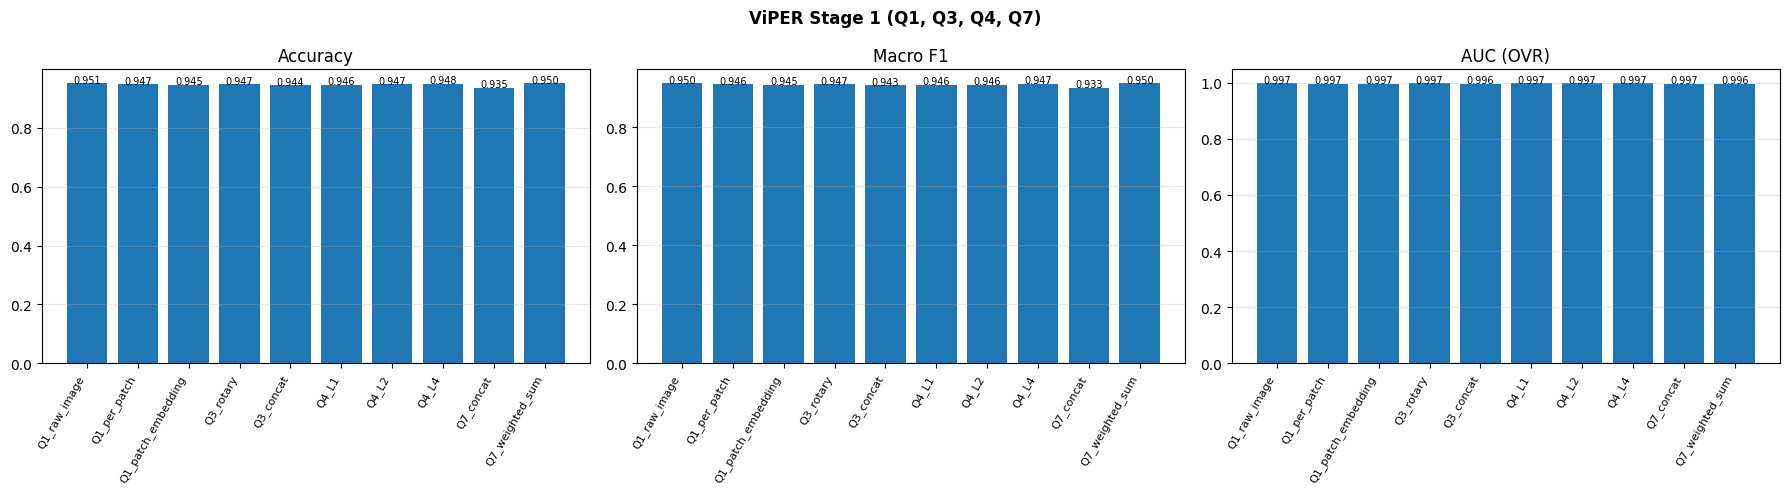

In [ ]:
def stage1_configs():
    base = dict(coef_to_patch="avg_pool", wavelet="db4",
                channel_mode="gray", level_combine="alw", sca=True)
    runs = []
    # Q1: dwt_location
    for loc in ["raw_image", "per_patch", "patch_embedding"]:
        runs.append((f"Q1_{loc}", ViPERConfig(
            dwt_location=loc, injection="additive", n_levels=3,
            subband_fusion="gated", **base)))
    # Q3: injection (raw_image fixed; additive in Q1 already)
    for inj in ["rotary", "concat"]:
        runs.append((f"Q3_{inj}", ViPERConfig(
            dwt_location="raw_image", injection=inj, n_levels=3,
            subband_fusion="gated", **base)))
    # Q4: n_levels (3 already covered)
    for L in [1, 2, 4]:
        runs.append((f"Q4_L{L}", ViPERConfig(
            dwt_location="raw_image", injection="additive", n_levels=L,
            subband_fusion="gated", **base)))
    # Q7: subband_fusion (gated already covered)
    for sf in ["concat", "weighted_sum"]:
        runs.append((f"Q7_{sf}", ViPERConfig(
            dwt_location="raw_image", injection="additive", n_levels=3,
            subband_fusion=sf, **base)))
    return runs


stage1_results = []
for name, cfg in stage1_configs():
    print(f"\n{'='*60}\n{name}\n{'='*60}")
    print(f"Config: {cfg}")
    try:
        r = train_one("viper", MODEL_PARAMS, cfg,
                      train_loader, val_loader, test_loader,
                      n_epochs=EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY,
                      device=DEVICE, num_classes=num_classes, seed=SEED,
                      name=name)
        stage1_results.append(r)
    except Exception as e:
        print(f"[ERROR] {name}: {e}")

df_stage1 = save_results(stage1_results, "stage1")
print("\n=== STAGE 1 RESULTS ===")
display(df_stage1)
plot_ablation(stage1_results, "ViPER Stage 1 (Q1, Q3, Q4, Q7)")


In [ ]:
# CPU-mode recovery cell — paste into a fresh notebook
from pathlib import Path
import json

OUT_DIR = Path("./viper_results")  # adjust if needed

# Check what's still on disk
if OUT_DIR.exists():
    print("Files found:")
    for f in sorted(OUT_DIR.iterdir()):
        print(f"  {f.name}  ({f.stat().st_size:,} bytes)")
else:
    print(f"{OUT_DIR} not found. You'll need to upload your saved files.")

viper_results not found. You'll need to upload your saved files.


In [ ]:
# ─── Reconstruct Stage 1 results from the printed table ────────────────────
from pathlib import Path
from dataclasses import dataclass, asdict
import json

OUT_DIR = Path("./viper_results")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Manually transcribed from your Stage 1 printed table
stage1_data = [
    # name,                pe_type,  test_acc, test_f1,  test_auc, best_val_acc, pe_params, epoch_t
    ("Q1_raw_image",       "viper",  0.950617, 0.949539, 0.997345, 0.945679,     79492,     30.018584),
    ("Q7_weighted_sum",    "viper",  0.950370, 0.949502, 0.996331, 0.944691,      3472,     27.886025),
    ("Q4_L4",              "viper",  0.948395, 0.947490, 0.996851, 0.943704,     80261,     30.104004),
    ("Q3_rotary",          "viper",  0.947160, 0.946769, 0.997212, 0.947901,     79492,     29.502028),
    ("Q1_per_patch",       "viper",  0.946914, 0.945713, 0.996596, 0.944198,     79492,     57.041156),
    ("Q4_L2",              "viper",  0.946667, 0.945507, 0.997155, 0.946914,     78723,     27.544788),
    ("Q4_L1",              "viper",  0.946420, 0.945566, 0.997413, 0.946667,     77954,     26.122781),
    ("Q1_patch_embedding", "viper",  0.945432, 0.944599, 0.996766, 0.947901,    116164,     29.513221),
    ("Q3_concat",          "viper",  0.944444, 0.943179, 0.996218, 0.940000,    153412,     28.985127),
    ("Q7_concat",          "viper",  0.934568, 0.933464, 0.996527, 0.936543,    151108,     27.632619),
]

stage1_results = []
for name, pe_type, acc, f1, auc, val_acc, pe_p, ep_t in stage1_data:
    stage1_results.append({
        "name":         name,
        "pe_type":      pe_type,
        "viper_cfg":    None,   # filled in below
        "seed":         42,
        "n_params":     None,
        "pe_params":    pe_p,
        "best_val_acc": val_acc,
        "test":         {"acc": acc, "f1": f1, "auc": auc, "loss": None},
        "history":      None,
        "avg_epoch_t":  ep_t,
    })

# Save so future sessions don't need this reconstruction
with open(OUT_DIR / "stage1_results.json", "w") as f:
    json.dump(stage1_results, f, indent=2)

print(f"Reconstructed {len(stage1_results)} Stage 1 runs.")
print(f"Saved: {OUT_DIR / 'stage1_results.json'}")

Reconstructed 10 Stage 1 runs.
Saved: viper_results/stage1_results.json


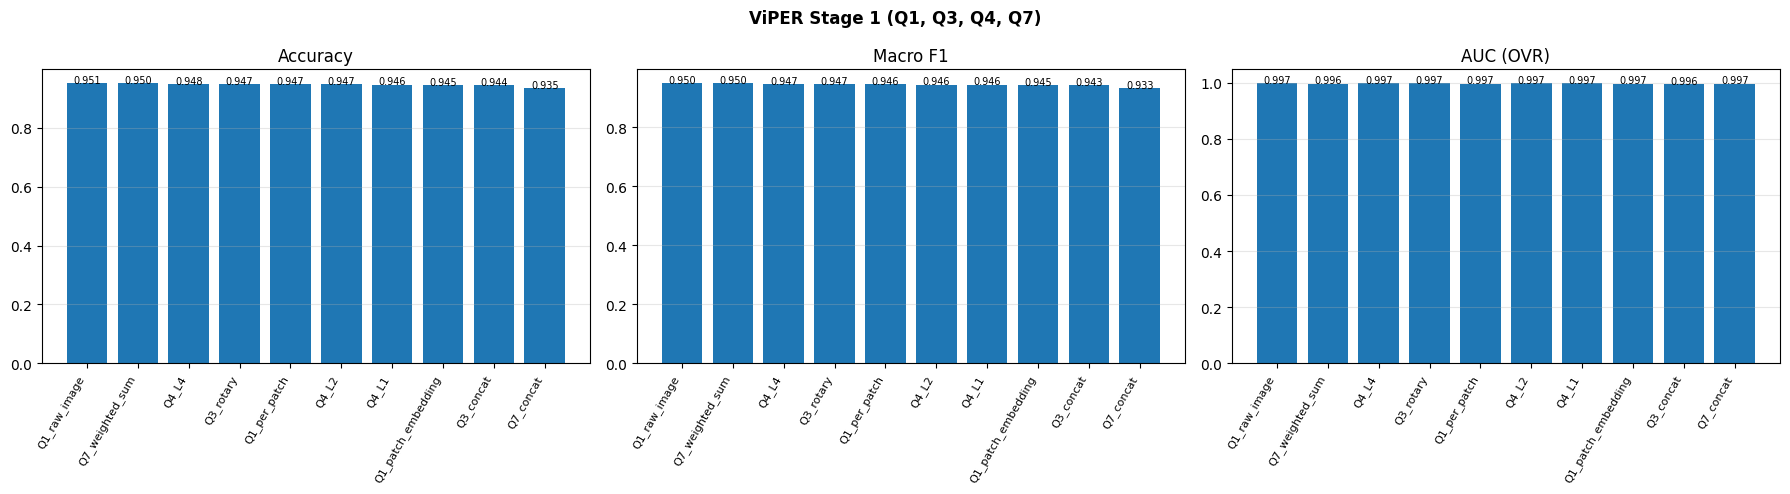

In [ ]:
import matplotlib.pyplot as plt
import math

names = [r["name"] for r in stage1_results]
accs  = [r["test"]["acc"] for r in stage1_results]
f1s   = [r["test"]["f1"]  for r in stage1_results]
aucs  = [r["test"]["auc"] for r in stage1_results]

fig, ax = plt.subplots(1, 3, figsize=(18, 5))
for a, vals, ttl in zip(ax, [accs, f1s, aucs], ["Accuracy", "Macro F1", "AUC (OVR)"]):
    bars = a.bar(range(len(names)), vals)
    a.set_xticks(range(len(names)))
    a.set_xticklabels(names, rotation=60, ha="right", fontsize=8)
    a.set_title(ttl); a.grid(True, alpha=0.3, axis="y")
    for b, v in zip(bars, vals):
        a.text(b.get_x() + b.get_width()/2, b.get_height() + 0.0005,
               f"{v:.3f}", ha="center", fontsize=7)
fig.suptitle("ViPER Stage 1 (Q1, Q3, Q4, Q7)", fontweight="bold")
plt.tight_layout()
plt.savefig("./viper_results/stage1.png", dpi=150, bbox_inches="tight")
plt.show()

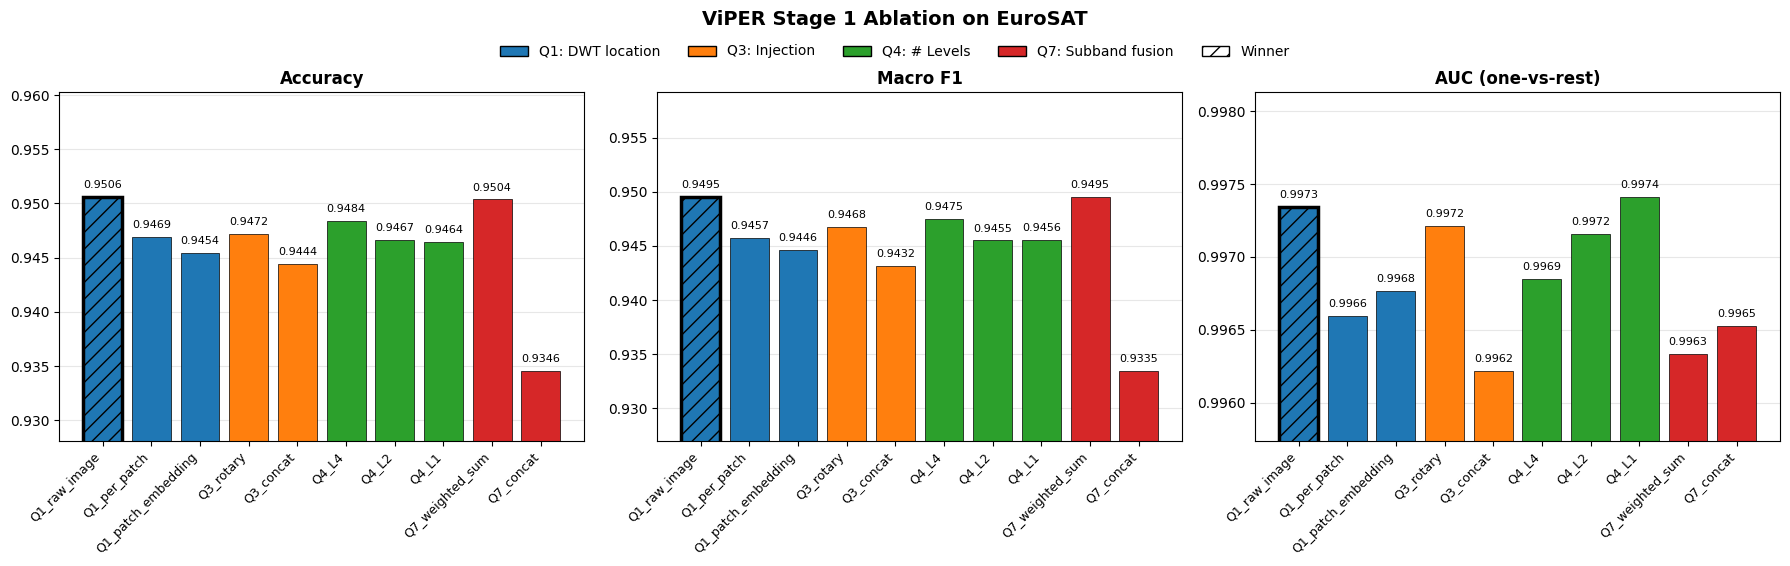

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Re-sort by axis for cleaner visual grouping
def axis_of(name):
    if name.startswith("Q1_"): return "Q1"
    if name.startswith("Q3_"): return "Q3"
    if name.startswith("Q4_"): return "Q4"
    if name.startswith("Q7_"): return "Q7"
    return "?"

# Group by axis
axis_order = ["Q1", "Q3", "Q4", "Q7"]
axis_colors = {"Q1": "#1f77b4", "Q3": "#ff7f0e", "Q4": "#2ca02c", "Q7": "#d62728"}

# Sort: by axis, then by accuracy within axis
sorted_runs = sorted(stage1_results,
                     key=lambda r: (axis_order.index(axis_of(r["name"])),
                                    -r["test"]["acc"]))

names = [r["name"] for r in sorted_runs]
accs  = [r["test"]["acc"] for r in sorted_runs]
f1s   = [r["test"]["f1"]  for r in sorted_runs]
aucs  = [r["test"]["auc"] for r in sorted_runs]
colors = [axis_colors[axis_of(n)] for n in names]

# Mark winner with hatching
winner_idx = int(np.argmax(accs))

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for ax, vals, ttl, fmt in zip(
    axes, [accs, f1s, aucs],
    ["Accuracy", "Macro F1", "AUC (one-vs-rest)"],
    ["{:.4f}", "{:.4f}", "{:.4f}"],
):
    bars = ax.bar(range(len(names)), vals, color=colors, edgecolor="black", linewidth=0.5)

    # Highlight winner
    bars[winner_idx].set_edgecolor("black")
    bars[winner_idx].set_linewidth(2.5)
    bars[winner_idx].set_hatch("//")

    # Zoom y-axis to make differences visible
    v_min, v_max = min(vals), max(vals)
    pad = (v_max - v_min) * 0.4 if v_max > v_min else 0.005
    ax.set_ylim(v_min - pad, v_max + pad * 1.5)

    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=45, ha="right", fontsize=9)
    ax.set_title(ttl, fontsize=12, fontweight="bold")
    ax.grid(True, alpha=0.3, axis="y")
    ax.set_axisbelow(True)

    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2,
                b.get_height() + (v_max - v_min) * 0.04,
                fmt.format(v), ha="center", va="bottom", fontsize=8)

# Legend for axis colors
from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=c, edgecolor="black",
                        label=f"{a}: {desc}")
                  for a, c, desc in [
                      ("Q1", axis_colors["Q1"], "DWT location"),
                      ("Q3", axis_colors["Q3"], "Injection"),
                      ("Q4", axis_colors["Q4"], "# Levels"),
                      ("Q7", axis_colors["Q7"], "Subband fusion"),
                  ]]
legend_handles.append(Patch(facecolor="white", edgecolor="black", hatch="//",
                            label="Winner"))
fig.legend(handles=legend_handles, loc="upper center",
           bbox_to_anchor=(0.5, 0.98), ncol=5, fontsize=10, frameon=False)

fig.suptitle("ViPER Stage 1 Ablation on EuroSAT", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("./viper_results/stage1_v2.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
import shutil
from google.colab import files

shutil.make_archive("viper_results", "zip", "./viper_results")
files.download("viper_results.zip")
print("Downloaded viper_results.zip — keep this safe.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded viper_results.zip — keep this safe.


## 14. Stage 2 ablation (Q5, Q6, Q8, SCA)

Refinement on top of the Stage 1 winner.

In [ ]:
# Determine winner
winner = max(stage1_results,
             key=lambda r: (r["test"]["acc"] if r["test"] else r["best_val_acc"]))
winner_cfg = ViPERConfig(**winner["viper_cfg"])
print(f"Stage 1 winner: {winner['name']}")
print(f"  acc={winner['test']['acc']:.4f}  f1={winner['test']['f1']:.4f}  auc={winner['test']['auc']:.4f}")
print(f"  config: {winner_cfg}")

with open(OUT_DIR / "stage1_winner.json", "w") as f:
    json.dump({"name": winner["name"], "cfg": asdict(winner_cfg)}, f, indent=2)


def stage2_configs(w):
    runs = []
    # Q5: wavelet
    for wav in ["haar", "sym4"]:
        c = ViPERConfig(**asdict(w)); c.wavelet = wav
        runs.append((f"Q5_{wav}", c))
    # Q6: channel_mode (only meaningful if dwt_location != patch_embedding)
    if w.dwt_location != "patch_embedding":
        for cm in ["per_channel_concat", "learnable_proj"]:
            c = ViPERConfig(**asdict(w)); c.channel_mode = cm
            runs.append((f"Q6_{cm}", c))
    # Q8: level_combine
    for lc in ["sum", "weighted"]:
        c = ViPERConfig(**asdict(w)); c.level_combine = lc
        runs.append((f"Q8_{lc}", c))
    # SCA off
    c = ViPERConfig(**asdict(w)); c.sca = False
    runs.append(("SCA_off", c))
    return runs


stage2_results = []
for name, cfg in stage2_configs(winner_cfg):
    print(f"\n{'='*60}\n{name}\n{'='*60}")
    print(f"Config: {cfg}")
    try:
        r = train_one("viper", MODEL_PARAMS, cfg,
                      train_loader, val_loader, test_loader,
                      n_epochs=EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY,
                      device=DEVICE, num_classes=num_classes, seed=SEED,
                      name=name)
        stage2_results.append(r)
    except Exception as e:
        print(f"[ERROR] {name}: {e}")

df_stage2 = save_results(stage2_results, "stage2")
print("\n=== STAGE 2 RESULTS ===")
display(df_stage2)
plot_ablation(stage2_results, "ViPER Stage 2 (Q5, Q6, Q8, SCA)")


Stage 1 winner: Q1_raw_image
  acc=0.9506  f1=0.9495  auc=0.9973
  config: ViPERConfig(dwt_location='raw_image', coef_to_patch='avg_pool', injection='additive', n_levels=3, wavelet='db4', channel_mode='gray', subband_fusion='gated', level_combine='alw', sca=True)

Q5_haar
Config: ViPERConfig(dwt_location='raw_image', coef_to_patch='avg_pool', injection='additive', n_levels=3, wavelet='haar', channel_mode='gray', subband_fusion='gated', level_combine='alw', sca=True)
[Q5_haar]  total=2,788,238  PE=79,492
  ep  10/50  tr=0.7907  val_acc=0.8756  f1=0.8720  auc=0.9922  t=29.0s
  ep  20/50  tr=0.6924  val_acc=0.9178  f1=0.9156  auc=0.9953  t=28.9s
  ep  30/50  tr=0.6162  val_acc=0.9254  f1=0.9231  auc=0.9966  t=28.8s


## 15. Final combined report

In [ ]:
all_results = baseline_results + stage1_results + stage2_results
df_all = save_results(all_results, "all")
print(f"\n=== ALL {len(all_results)} RUNS ===")
display(df_all)

# Top-5
print("\n=== TOP 5 ===")
display(df_all.head(5))

# Best ViPER vs best baseline
viper_runs    = [r for r in all_results if r["pe_type"] == "viper"]
baseline_runs_ = [r for r in all_results if r["pe_type"] != "viper"]
if viper_runs and baseline_runs_:
    best_v = max(viper_runs, key=lambda r: r["test"]["acc"])
    best_b = max(baseline_runs_, key=lambda r: r["test"]["acc"])
    delta = (best_v["test"]["acc"] - best_b["test"]["acc"]) * 100
    print(f"\nBest ViPER:    {best_v['name']:25s}  acc={best_v['test']['acc']:.4f}")
    print(f"Best baseline: {best_b['name']:25s}  acc={best_b['test']['acc']:.4f}")
    print(f"Delta:                                      {delta:+.2f} pp")

print(f"\nAll outputs saved to: {OUT_DIR.resolve()}")


## 16. Download results (Colab only)

Zip the results folder and download.

In [ ]:
# Uncomment in Colab to download results as a zip
# import shutil
# shutil.make_archive("viper_results", "zip", OUT_DIR)
# from google.colab import files
# files.download("viper_results.zip")
print("To download: uncomment the lines above (requires running in Colab).")
